In [7]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [8]:
# General info
path_arrays = "/g/data/up6/ai2733/Gusts_downdrafts/data/arrays/"
path_figs   = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"

lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}
name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}


## Read mean profiles

In [9]:
cases = ["CASE2_new", 'CASE2_new_testmp']
domains = ["d02", "d03"]

In [10]:
# Coarsen grid 80 km from AWS
vars_read = ["pressure", "height"]
prof_coarsen_all = {stage: {} for stage in ["All"]}
for case in cases:
    for dom in domains:
        for var in vars_read:
            key = f"{var}_{case}_{dom}"
            file_coar = f'{path_arrays}TimeProf_CASE2_new_{dom}_{var}_80kmAWS_coarsen.npy' # Same for both!
            time_prof_coarsen_all = np.load(file_coar)                
            prof_coarsen_all["All"][key] = time_prof_coarsen_all.mean(axis = 0)

## Read arrays of vertical velocity (filtered)

In [11]:
# Read arrays of vertical velocity (filtered)
read_w = True
thr = 5
if read_w:
    prefix = f'new{int(thr)}_'
    wa_down_strongest_below, wa_down_strongest_above = {},  {}
    wa_up_strongest_below, wa_up_strongest_above = {},  {}

    # Merge coarsen
    for case in cases:
        for dom in domains:
            key = f"{case}_{dom}_coarsen"
            # Load 
            with open(f"{path_arrays}/{prefix}wa_down_strongest_below_{case}_{dom}coarsen.pkl", "rb") as f: wa_down_strongest_below[key] = pickle.load(f)
            with open(f"{path_arrays}/{prefix}wa_down_strongest_above_{case}_{dom}coarsen.pkl", "rb") as f: wa_down_strongest_above[key] = pickle.load(f)
            with open(f"{path_arrays}/{prefix}wa_up_strongest_below_{case}_{dom}coarsen.pkl", "rb") as f: wa_up_strongest_below[key] = pickle.load(f)
            with open(f"{path_arrays}/{prefix}wa_up_strongest_above_{case}_{dom}coarsen.pkl", "rb") as f: wa_up_strongest_above[key] = pickle.load(f)

In [12]:
# Merge below and above FL
wa_down_strongest_all = {}
wa_up_strongest_all    = {}
for key in wa_down_strongest_below.keys():
    wa_down_strongest_all[key] = {}
    wa_up_strongest_all[key]   = {}
    for key2 in wa_down_strongest_below[key].keys():
         wa_down_strongest_all[key][key2] = np.where(~np.isnan(wa_down_strongest_below[key][key2]),  wa_down_strongest_below[key][key2], wa_down_strongest_above[key][key2])
         wa_up_strongest_all[key][key2]   = np.where(~np.isnan(wa_up_strongest_below[key][key2]),    wa_up_strongest_below[key][key2],   wa_up_strongest_above[key][key2])

In [13]:
# Total counts with different thresholds: Updrafts 
counts_all_up_below = {}
counts_all_up_above = {}
counts_all_up_all   = {}
for thr in [5.0, 8.0, 12.0]: #, -15.0]:
    counts_all_up_below[thr] = {}
    counts_all_up_above[thr] = {}
    counts_all_up_all[thr] = {}
    for key in wa_up_strongest_above.keys():
        counts_all_up_below[thr][key] = {}
        counts_all_up_above[thr][key] = {}
        counts_all_up_all[thr][key]   = {}
        for key2 in wa_up_strongest_above[key].keys():
            arr = wa_up_strongest_below[key][key2]
            mask = (arr >= thr) & (~np.isnan(arr))
            counts_all_up_below[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_up_strongest_above[key][key2]
            mask = (arr >= thr) & (~np.isnan(arr))
            counts_all_up_above[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_up_strongest_all[key][key2]
            mask = (arr >= thr) & (~np.isnan(arr))
            counts_all_up_all[thr][key][key2] = np.count_nonzero(mask)
             

In [14]:
# Total counts with different thresholds: downdrafts 
counts_all_down_below = {}
counts_all_down_above = {}
counts_all_down_all   = {}
for thr in [-5.0, -8.0, -12.0]: #, -15.0]:
    counts_all_down_below[thr] = {}
    counts_all_down_above[thr] = {}
    counts_all_down_all[thr] = {}
    for key in wa_down_strongest_above.keys():
        counts_all_down_below[thr][key] = {}
        counts_all_down_above[thr][key] = {}
        counts_all_down_all[thr][key]   = {}
        for key2 in wa_down_strongest_above[key].keys():
            arr = wa_down_strongest_below[key][key2]
            mask = (arr <= thr) & (~np.isnan(arr))
            counts_all_down_below[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_down_strongest_above[key][key2]
            mask = (arr <= thr) & (~np.isnan(arr))
            counts_all_down_above[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_down_strongest_all[key][key2]
            mask = (arr <= thr) & (~np.isnan(arr))
            counts_all_down_all[thr][key][key2] = np.count_nonzero(mask)
             

## Figure S7: Downdrafts all levels

In [15]:
def plot_counts_and_profiles(counts_all, dic_wa, thresholds=[-5., -8., -12.]):
    """""""""""""""""""""""""""""""""""""""""""""""""""
    # Plot counts and profiles: 1 km versus 200 m: for downdrafts
    """""""""""""""""""""""""""""""""""""""""""""""""""

    # Font settings
    fs = 22
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-4,
        "ytick.labelsize": fs-4,
        "legend.fontsize": fs,
        "figure.titlesize": fs,
        "font.family": "Times New Roman",
    })
    
    # Config
    cases   = ['CASE2_new', 'CASE2_new_testmp']
    cases1  = ['MP = NSSL', 'MP = Milbrandt-Yau']
    datasets = ['1 km', '200 m coarsen to 1 km']
    colors_  = ["orange", "green"]
    width    = 0.35
    
    # Grid:
    fig, axes = plt.subplots(nrows=len(thresholds), ncols=3, figsize=(18, 14), sharey=False, constrained_layout=True)

    # Loop thresholds (rows)
    for r, thr in enumerate(thresholds):
        ## ----- bar plot of total counts -----
        stage = "All"
        counts_plot = []
        for case in cases:
            arr1 = counts_all[thr][f"{case}_d02_coarsen"][f"{case}_d02_{stage}"]
            arr2 = counts_all[thr][f"{case}_d03_coarsen"][f"{case}_d03_{stage}"]
            counts_plot.append([arr1, arr2])
        counts_plot = np.array(counts_plot)

        ax1 = axes[r, 0]
        x = np.arange(len(cases))
        for i, dataset in enumerate(datasets):
            ax1.bar(x + i*width, counts_plot[:, i], width,
                    label=dataset, color=colors_[i])
        ax1.set_xticks(x + width/2)
        ax1.set_xticklabels(cases1)
        ax1.set_ylabel("Count (below freezing level)")
        #if r == 0:
        #    ax1.legend(frameon=False, loc = 2)
        ax1.set_title(f"Downdrafts ≤ {int(thr)} m/s", fontweight = "bold")

        # --- Relative difference line ---
        diff = 100 * (counts_plot[:, 1] - counts_plot[:, 0]) / counts_plot[:, 0]
        
        ax2 = ax1.twinx()
        ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
        ax2.axhline(0, color="gray", lw=1, ls=":")
        ax2.set_ylabel("Relative difference [%]", labelpad=14, rotation=270)
        
        # Optional: make both y-axes align nicely
        #ax2.set_ylim(min(-20, diff.min() - 5), max(60, diff.max() + 5))
        ax2.set_ylim(0,500)
        ax2.yaxis.label.set_color("k")
        ax2.tick_params(axis='y', colors='k')
        
        for xi, d in zip(x, diff):
            ax2.text(xi + width/2, d + 1, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

        lines, labels = ax2.get_legend_handles_labels()
        bars, bar_labels = ax1.get_legend_handles_labels()
    
        ## -----vertical distributions per case -----
        for c, case in enumerate(cases):
            ax2 = axes[r, c+1]   # shift by +1 since col0 is bar plot
            for dom, name in zip(domains, ["1 km", "200 m coarsen to 1 km"]):
                height_meanprof = prof_coarsen_all["All"][f"pressure_{case}_{dom}"]
                wa_strong = dic_wa[f'{case}_{dom}_coarsen'][f'{case}_{dom}_All']
                wa_strong_masked = np.where(wa_strong <= thr, wa_strong, np.NaN)
                counts_strong = np.sum(~np.isnan(wa_strong_masked), axis=(0,2,3))
                ax2.plot(counts_strong, height_meanprof, 
                         label=f"{name}",
                         lw=3.0,
                         color="green" if dom == "d03" else "orange")
            ax2.invert_yaxis()
            ax2.axvline(x=0, ls="--", color="grey")
            ax2.grid(axis = "y", ls = "--", c = "grey")
            if r == 0:
                ax2.set_title(cases1[c])
            if c == 0:
                ax2.set_ylabel("Pressure [hPa]", labelpad=0.)
            if r == len(thresholds)-1:
                ax2.set_xlabel("Count")
            #if r == 0 and c == 0:
            #    ax2.legend(frameon=False, loc = 1)

    ## ----- Add panel label (a), b), c) …) -----
    panel_labels = ["a)", "b)", "c)"]
    label_x = 0.03       # horizontal position in figure coordinates (0 = left, 1 = right)
    label_ys = [0.96, 0.65, 0.32]  # vertical positions for each row (top to bottom)
    
    for r, thr in enumerate(thresholds):
        panel_label = panel_labels[r]
        fig.text(label_x-0.02, label_ys[r]+0.02, panel_label, va="center", ha="left", 
                 fontsize=fs+2, fontweight="bold")

    fig.legend(bars + lines, bar_labels + labels,
               loc="upper center", ncol=3, frameon=False, fontsize=fs+2, bbox_to_anchor=(0.5, 1.05))

    plt.savefig(f"{path_figs}/FigureS7.png", dpi = 300, bbox_inches = "tight")
    plt.show()

/jobfs/168719317.gadi-pbs/ipykernel_74367/2418456903.py:53: RuntimeWarning: divide by zero encountered in divide
  diff = 100 * (counts_plot[:, 1] - counts_plot[:, 0]) / counts_plot[:, 0]


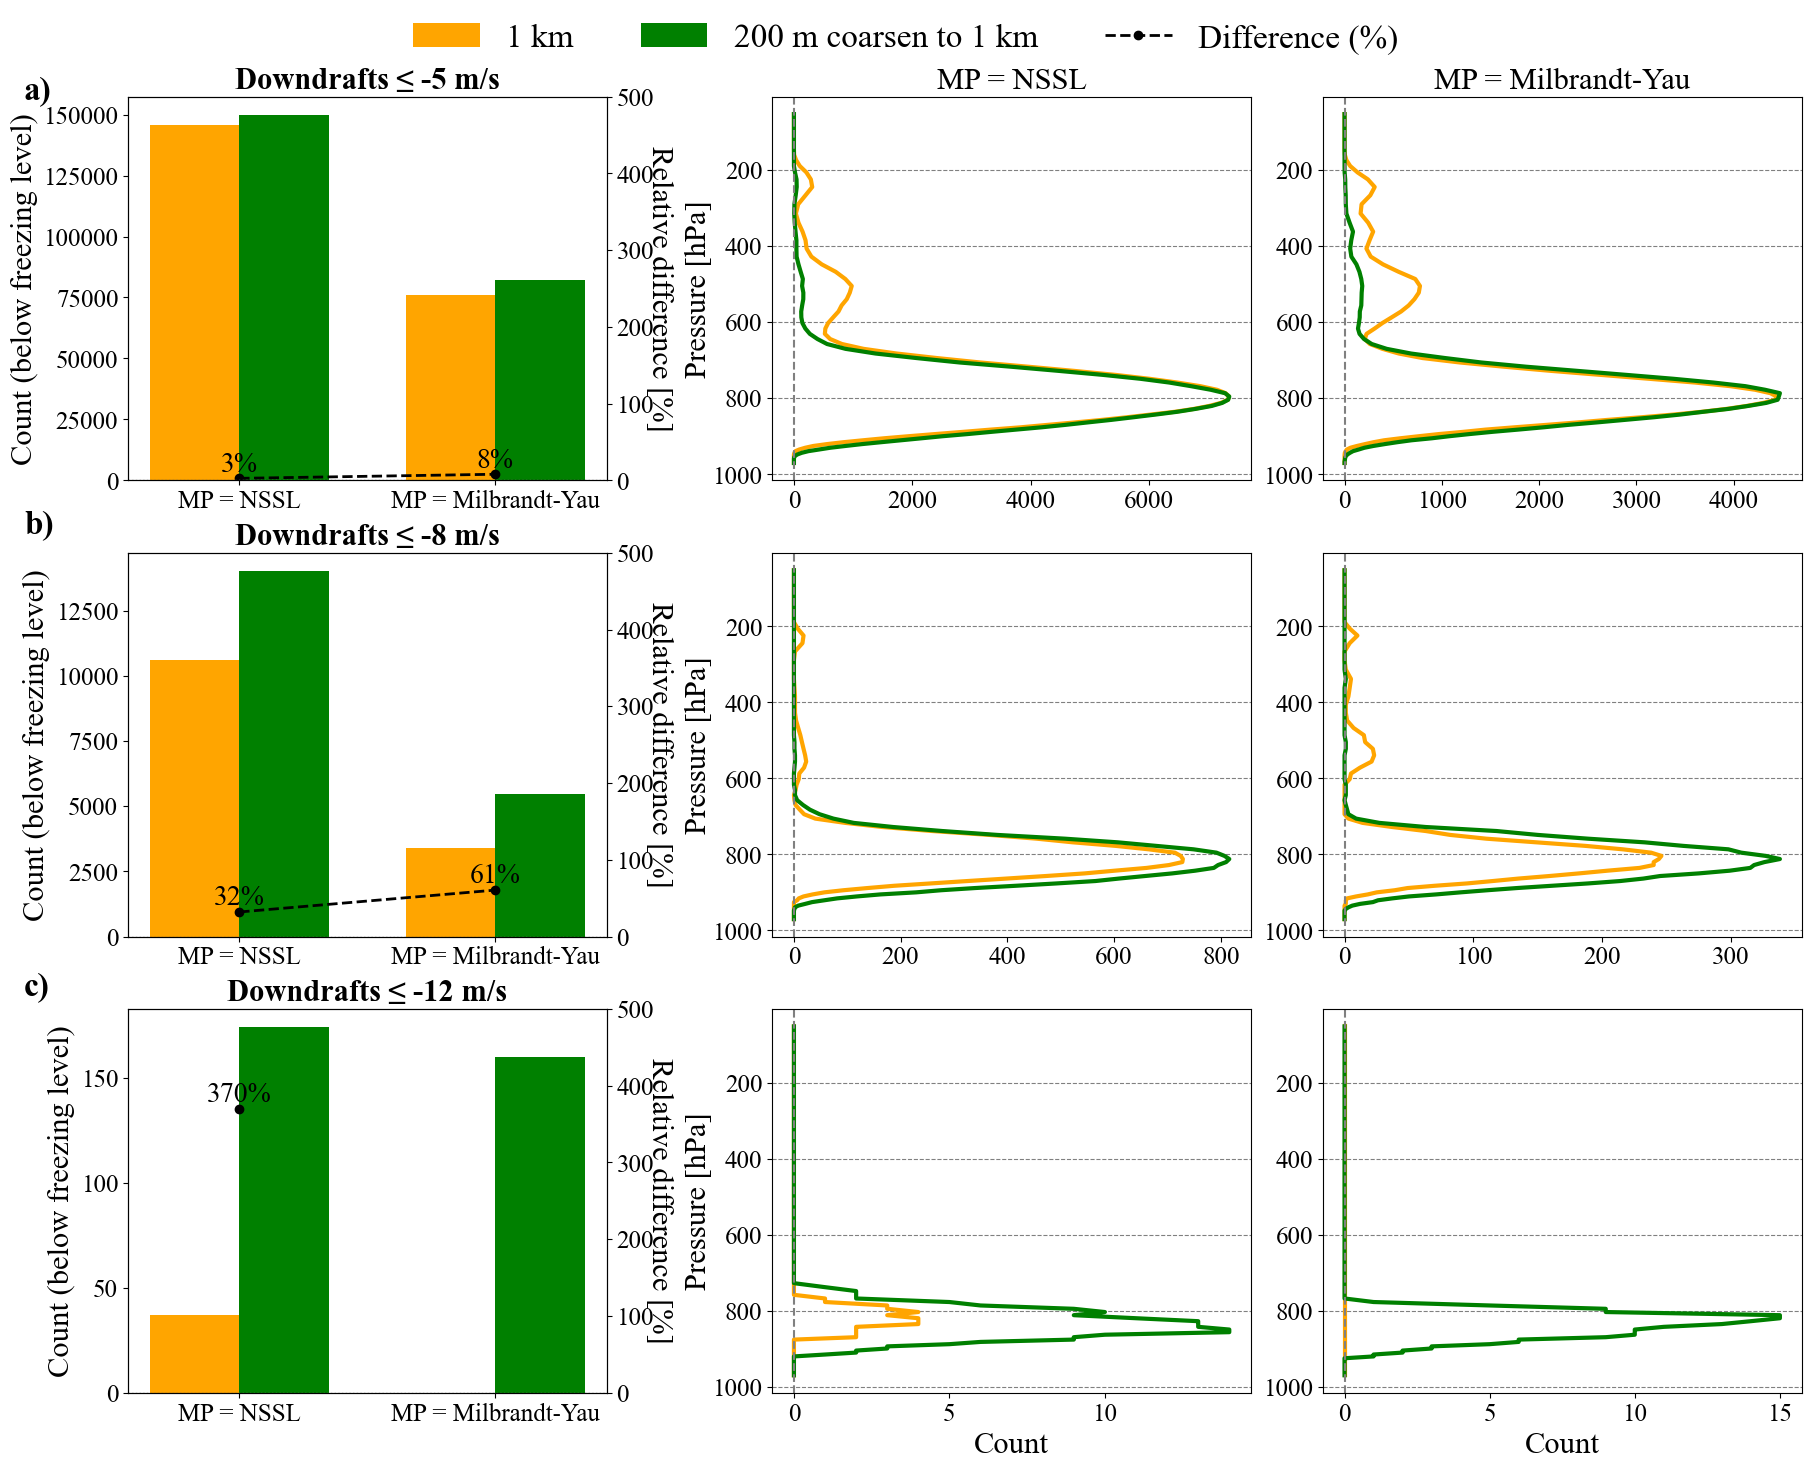

In [16]:
plot_counts_and_profiles(counts_all_down_below, wa_down_strongest_all, thresholds=[-5., -8., -12.])

## Figure S8: Updrafts all levels

In [18]:
def plot_counts_and_profiles_up(counts_all, dic_wa, thresholds=[5., 8., 12.]):
    """""""""""""""""""""""""""""""""""""""""""""""""""
    # Plot counts and profiles: 1 km versus 200 m: for updrafts
    """""""""""""""""""""""""""""""""""""""""""""""""""

    # Font settings
    fs = 20
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-4,
        "ytick.labelsize": fs-4,
        "legend.fontsize": fs-4,
        "figure.titlesize": fs+2,
        "font.family": "Times New Roman",
    })
    
    # Config
    cases   = ['CASE2_new', 'CASE2_new_testmp']
    cases1  = ['MP = NSSL', 'MP = Milbrandt-Yau']
    datasets = ['1 km', '200 m coarsen to 1 km']
    colors_  = ["orange", "green"]
    width    = 0.35
    
    # Grid: 3 thresholds × (1 bar + 3 profiles = 4 columns)
    fig, axes = plt.subplots(nrows=len(thresholds), ncols=3, figsize=(17, 14), sharey=False, constrained_layout=True)

    # Loop thresholds (rows)
    for r, thr in enumerate(thresholds):
        ## ----- Column 1: bar plot of total counts -----
        stage = "All"
        counts_plot = []
        for case in cases:
            arr1 = counts_all[thr][f"{case}_d02_coarsen"][f"{case}_d02_{stage}"]
            arr2 = counts_all[thr][f"{case}_d03_coarsen"][f"{case}_d03_{stage}"]
            counts_plot.append([arr1, arr2])
        counts_plot = np.array(counts_plot)

        ax1 = axes[r, 0]
        x = np.arange(len(cases))
        for i, dataset in enumerate(datasets):
            ax1.bar(x + i*width, counts_plot[:, i], width,
                    label=dataset, color=colors_[i])
        ax1.set_xticks(x + width/2)
        ax1.set_xticklabels(cases1)
        ax1.set_ylabel("Count (below freezing level)")
        ax1.set_title(f"Updrafts >= {int(thr)} m/s", fontweight = "bold")

        # --- Relative difference line ---
        diff = 100 * (counts_plot[:, 1] - counts_plot[:, 0]) / counts_plot[:, 0]
        
        ax2 = ax1.twinx()
        ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
        ax2.axhline(0, color="gray", lw=1, ls=":")
        ax2.set_ylabel("Relative difference [%]", labelpad=12, rotation=270)
        
        # Optional: make both y-axes align nicely
        ax2.set_ylim(-45,45)
        ax2.yaxis.label.set_color("k")
        ax2.tick_params(axis='y', colors='k')
        
        # --- Optional annotations for clarity ---
        for xi, d in zip(x, diff):
            ax2.text(xi + width/2, d + 1, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

        lines, labels = ax2.get_legend_handles_labels()
        bars, bar_labels = ax1.get_legend_handles_labels()
    
        ## ----- Columns 2–4: vertical distributions per case -----
        for c, case in enumerate(cases):
            ax2 = axes[r, c+1]   # shift by +1 since col0 is bar plot
            for dom, name in zip(domains, ["1 km", "200 m coarsen to 1 km"]):
                height_meanprof = prof_coarsen_all["All"][f"pressure_{case}_{dom}"]
                wa_strong = dic_wa[f'{case}_{dom}_coarsen'][f'{case}_{dom}_All']
                wa_strong_masked = np.where(wa_strong >= thr, wa_strong, np.NaN)
                counts_strong = np.sum(~np.isnan(wa_strong_masked), axis=(0,2,3))
                ax2.plot(counts_strong, height_meanprof, 
                         label=f"{name}",
                         lw=3.0,
                         color="green" if dom == "d03" else "orange")
            ax2.invert_yaxis()
            ax2.axvline(x=0, ls="--", color="grey")
            ax2.grid(axis = "y", ls = "--", c = "grey")
            if r == 0:
                ax2.set_title(cases1[c])
            if c == 0:
                ax2.set_ylabel("Pressure [hPa]", labelpad=0.)
            if r == len(thresholds)-1:
                ax2.set_xlabel("Count")
            #if r == 0 and c == 0:
            #    ax2.legend(frameon=False, loc = 1)

    ## ----- Add panel label (a), b), c) …) -----
    panel_labels = ["a)", "b)", "c)"]
    label_x = 0.03       # horizontal position in figure coordinates (0 = left, 1 = right)
    label_ys = [0.96, 0.65, 0.32]  # vertical positions for each row (top to bottom)
    
    for r, thr in enumerate(thresholds):
        panel_label = panel_labels[r]
        fig.text(label_x-0.02, label_ys[r]+0.02, panel_label, va="center", ha="left", 
                 fontsize=fs+2, fontweight="bold")


    fig.legend(bars + lines, bar_labels + labels,
               loc="upper center", ncol=3, frameon=False, fontsize=fs+1, bbox_to_anchor=(0.5, 1.05))

    plt.savefig(f"{path_figs}/FigureS8.png", dpi = 300, bbox_inches = "tight")
    plt.show()

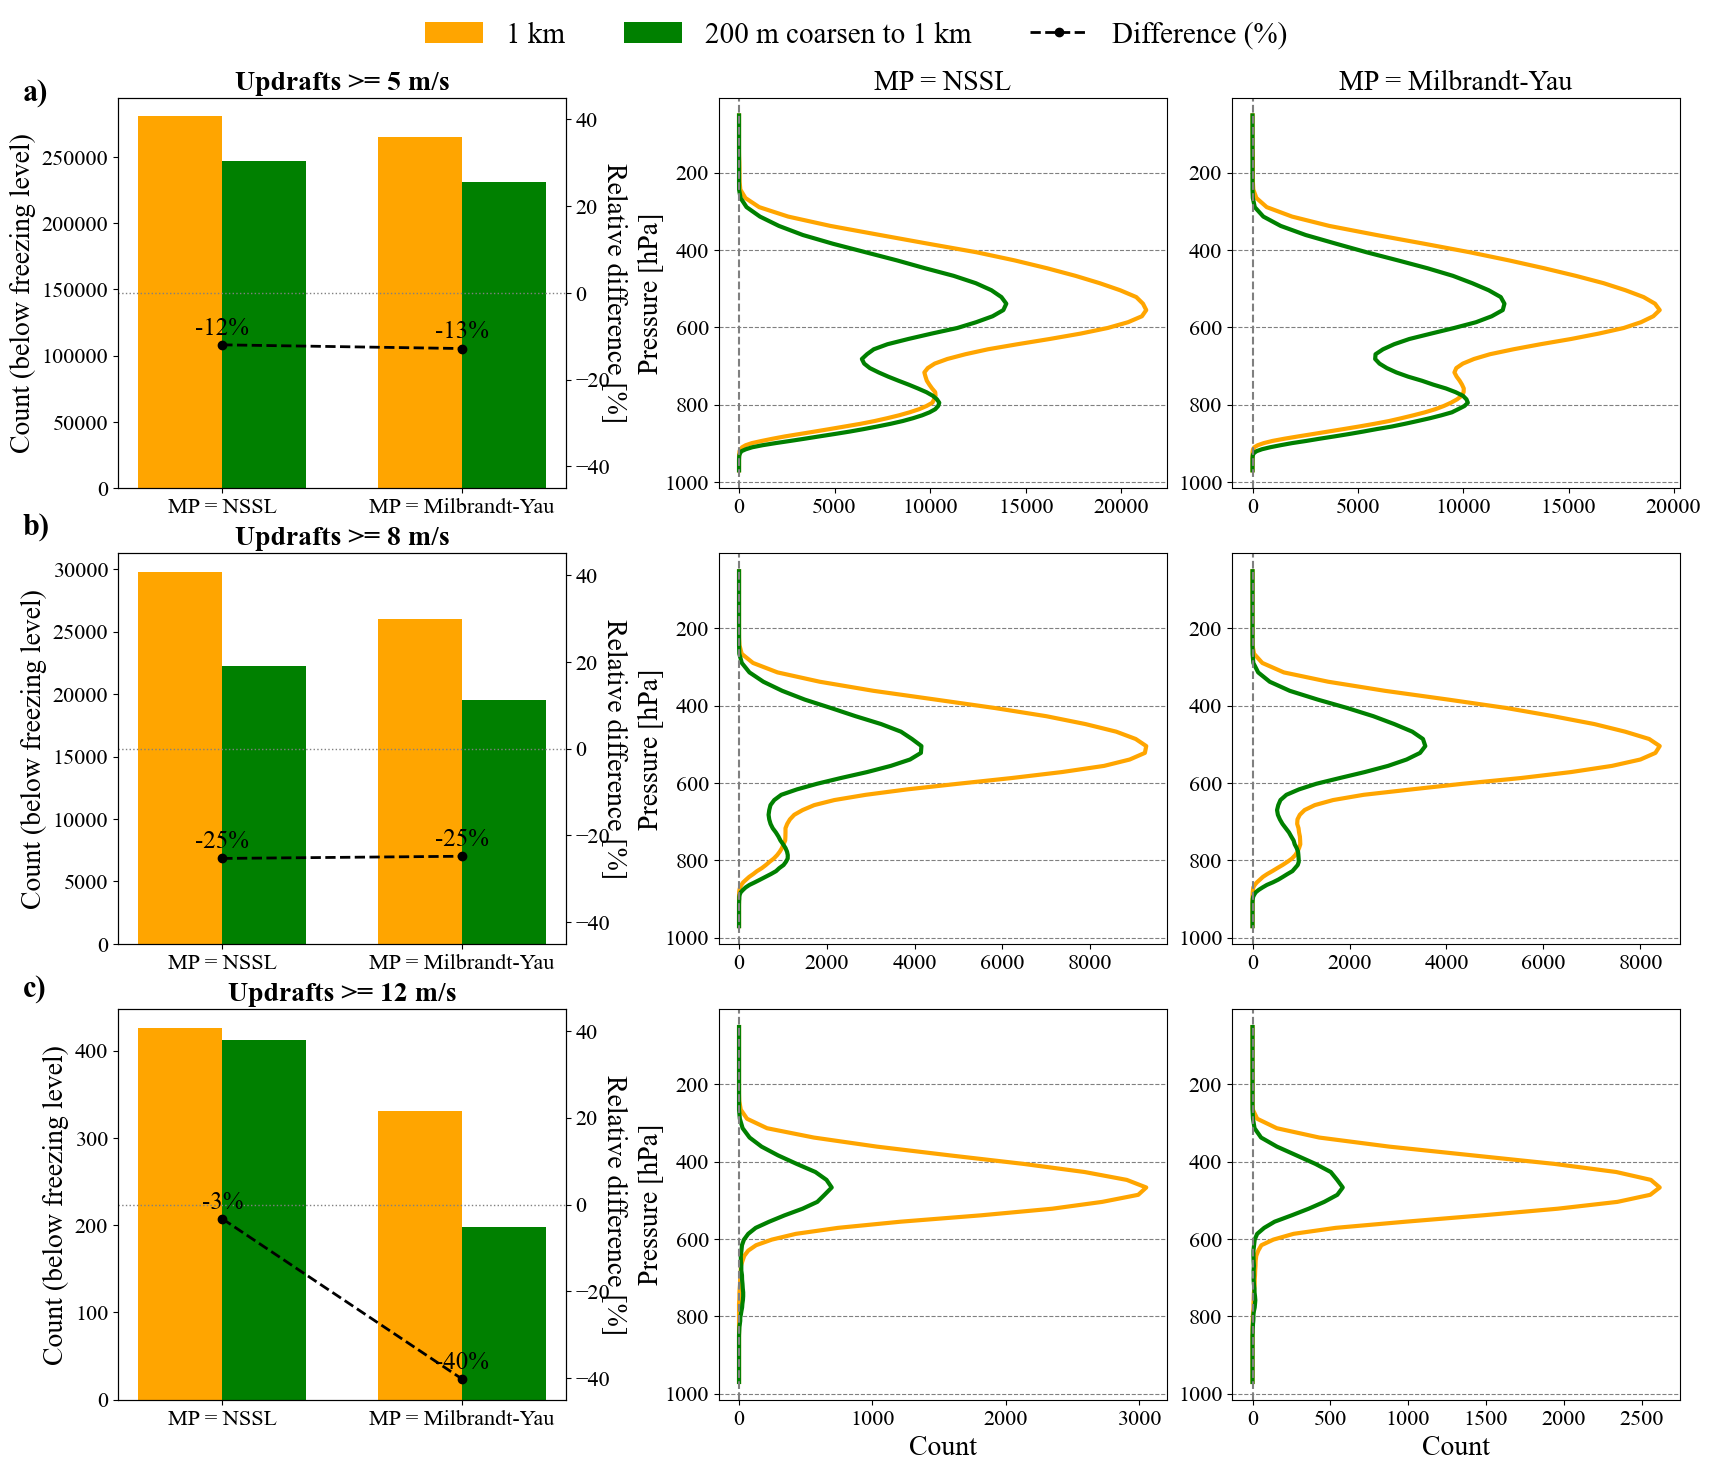

In [19]:
plot_counts_and_profiles_up(counts_all_up_below, wa_up_strongest_all, thresholds=[5., 8., 12.])